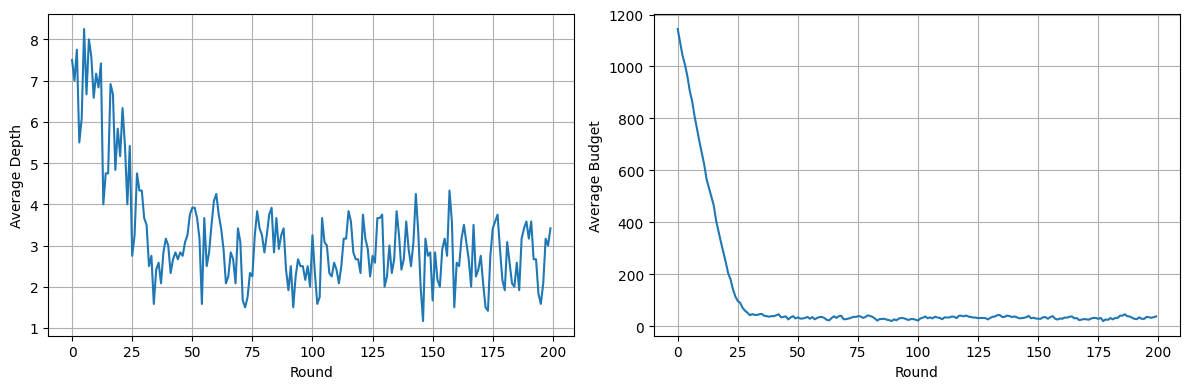

,round,avg_depth,depth_var,avg_budget,avg_curv
195,195,1.583333,1.076389,35.916667,-3.7
196,196,2.083333,1.076389,34.833333,-3.7
197,197,3.166667,3.305556,32.583333,-3.7
198,198,3.000000,1.666667,35.000000,-3.7
199,199,3.416667,2.243056,38.000000,-3.7


In [2]:
import networkx as nx
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------------- CONFIG ---------------- #
N_AGENTS      = 12
EDGE_PROB     = 0.25
INIT_BUDGET   = 1200
DEPTH_COST    = 7
MAX_DEPTH     = 15
RECOVER       = 10
ROUNDS        = 200
random.seed(42)

# ------------ quick Forman‑Ricci proxy ------------ #
def ricci_curvature(G):
    curv = {}
    for u, v in G.edges():
        deg_u, deg_v = G.degree[u], G.degree[v]
        curv[(u, v)] = 1.0 * (4 - (deg_u + deg_v))
    return curv

# ------------ initialise swarm ------------ #
G = nx.erdos_renyi_graph(N_AGENTS, EDGE_PROB)
for n in G.nodes():
    G.nodes[n]['budget'] = INIT_BUDGET
    G.nodes[n]['depth']  = 0

history = []

# ------------ main loop ------------ #
for t in range(ROUNDS):
    curv = ricci_curvature(G)  # precompute curvature once per round

    for a in G.nodes():
        # Regenerate tokens
        G.nodes[a]['budget'] = min(G.nodes[a]['budget'] + RECOVER, INIT_BUDGET)

        desired = random.randint(1, MAX_DEPTH)
        cost    = desired * DEPTH_COST

        if G.nodes[a]['budget'] >= cost:
            G.nodes[a]['budget'] -= cost
            G.nodes[a]['depth']   = desired

            for nb in G.neighbors(a):
                # Curvature-weighted influence factor
                edge = (a, nb) if (a, nb) in curv else (nb, a)
                influence = max(0.2, 1 + curv.get(edge, 0) / 10)

                # Cooperation bonus if same depth
                coop_bonus = 1.1 if G.nodes[nb]['depth'] == G.nodes[a]['depth'] else 1.0

                new_depth = int(0.6 * G.nodes[nb]['depth'] + 0.4 * desired * influence * coop_bonus)
                G.nodes[nb]['depth'] = min(MAX_DEPTH, new_depth)

    depths   = np.array([G.nodes[n]['depth']  for n in G.nodes()])
    budgets  = np.array([G.nodes[n]['budget'] for n in G.nodes()])
    curv_avg = np.mean(list(curv.values()))

    history.append(dict(round=t,
                        avg_depth=depths.mean(),
                        depth_var=depths.var(),
                        avg_budget=budgets.mean(),
                        avg_curv=curv_avg))

df = pd.DataFrame(history)

# ------------- quick plots ------------- #
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(df['round'], df['avg_depth']);  ax[0].set_ylabel('Average Depth')
ax[1].plot(df['round'], df['avg_budget']); ax[1].set_ylabel('Average Budget')
for a in ax: a.set_xlabel('Round'); a.grid(True)
plt.tight_layout(); plt.show()

df.tail()  # peek
